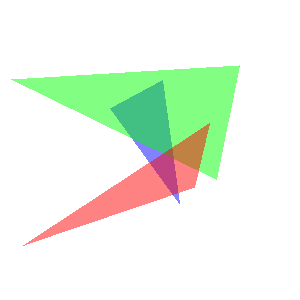

In [1]:
from PIL import Image, ImageDraw

polygons = [
    {'vertices': [(179, 203), (162, 80), (110, 108)],
     'RGBA': (0, 0, 255, 125)},
    {'vertices': [(239, 65), (216, 179), (11, 79)], 'RGBA': (0, 255, 0, 125)},
    {'vertices': [(209, 123), (23, 245), (194, 187)], 'RGBA': (255, 0, 0, 125)}
]


def draw(polygons, size):
    """ Функция для рисования многоугольников """

    img = Image.new('RGB', (size[0], size[1]), (255, 255, 255))
    drw = ImageDraw.Draw(img, 'RGBA')

    for pol in polygons:
        drw.polygon(pol['vertices'], pol['RGBA'])

    return (img.convert("RGB"))


draw(polygons, size=(300, 300))

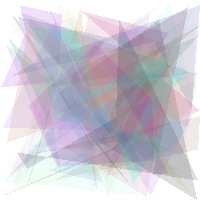

In [2]:
import numpy as np


def random_triangles(N, size, vertices=3, colour="random", alpha="random"):
    """ Функция создания популяции рандомных треугольников """

    collection = []

    for i in range(N):
        coords = [(np.random.randint(0, size[0]), np.random.randint(0, size[1]))
                  for i in range(vertices)]

        if alpha == "random":
            a = np.random.randint(0, 50)
        else:
            a = alpha

        if colour == "white":
            rgba = (255, 255, 255, a)
        elif colour == "black":
            rgba = (0, 0, 0, a)
        elif colour == "random":
            rgba = (np.random.randint(0, 256), np.random.randint(
                0, 256), np.random.randint(0, 256), a)

        triangle = {"vertices": coords, "RGBA": rgba}
        collection.append(triangle)

    return (collection)


collection = random_triangles(N=50, size=(
    200, 200), vertices=5, colour="random", alpha="random")
img = draw(collection, size=(200, 200))
img

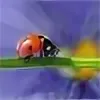

In [4]:
image_path = "bug.png"
target = Image.open(image_path).convert("RGB")
target

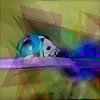

In [5]:
from PIL import ImageChops

ImageChops.difference(img, target)

In [6]:
def pixel_difference(candidate, target):
    """ Функция для попиксельного вычисления отличий между картинками"""
    diff = ImageChops.difference(candidate, target)
    totdiff = np.array(diff.getdata()).sum()
    return (totdiff)


diff = pixel_difference(img, target)
diff

C:\Users\Admin\AppData\Local\Temp\ipykernel_10820\2062916782.py:4: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  totdiff = np.array(diff.getdata()).sum()


np.int64(2957701)

In [7]:
def max_pixel_difference(target):
    """ Функция вычисления максимально возможной разницы между изображениями"""
    white = Image.new('RGB', target.size, (255, 255, 255))
    diff = ImageChops.difference(white, target)
    maxdiff = np.array(diff.getdata()).sum()
    return (maxdiff)


maxdiff = max_pixel_difference(target)
fitness = (1 - diff / maxdiff) * 100
print("Fitness = " + str(np.round(fitness, 4)) + "%")

Fitness = 30.7783%


C:\Users\Admin\AppData\Local\Temp\ipykernel_10820\473874746.py:5: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  maxdiff = np.array(diff.getdata()).sum()


In [8]:
import copy
import matplotlib.pyplot as plt


# ==================== ОПЕРАТОРЫ МУТАЦИЙ ====================

def _random_polygon(size, num_verts=3):
    """Создание случайного многоугольника"""
    width, height = size
    vertices = [
        (int(np.random.randint(-10, width + 10)),
         int(np.random.randint(-10, height + 10)))
        for _ in range(num_verts)
    ]
    rgba = (
        int(np.random.randint(0, 256)),
        int(np.random.randint(0, 256)),
        int(np.random.randint(0, 256)),
        int(np.random.randint(0, 51))
    )
    return {'vertices': vertices, 'RGBA': rgba}


def binary_mutation(individual, size):
    """Двоичная мутация — замена случайного гена (полигона) на новый случайный"""
    mutated = copy.deepcopy(individual)
    if not mutated:
        return mutated
    idx = np.random.randint(0, len(mutated))
    num_verts = len(mutated[idx]['vertices'])
    mutated[idx] = _random_polygon(size, num_verts=num_verts)
    return mutated


def append_mutation(individual, size, num_verts=3):
    """Присоединение — добавление случайного гена в конец хромосомы"""
    mutated = copy.deepcopy(individual)
    mutated.append(_random_polygon(size, num_verts=num_verts))
    return mutated


def insert_mutation(individual, size, num_verts=3):
    """Вставка — вставка случайного гена в случайную позицию"""
    mutated = copy.deepcopy(individual)
    pos = np.random.randint(0, len(mutated) + 1)
    mutated.insert(pos, _random_polygon(size, num_verts=num_verts))
    return mutated


def delete_mutation(individual):
    """Удаление — удаление случайного гена из хромосомы"""
    mutated = copy.deepcopy(individual)
    if len(mutated) <= 1:
        return mutated
    idx = np.random.randint(0, len(mutated))
    del mutated[idx]
    return mutated


def swap_mutation(individual):
    """Обмен — обмен местами случайного гена с его соседом"""
    mutated = copy.deepcopy(individual)
    if len(mutated) < 2:
        return mutated
    idx = np.random.randint(0, len(mutated) - 1)
    mutated[idx], mutated[idx + 1] = mutated[idx + 1], mutated[idx]
    return mutated


def mutation(individual, size, pmut=0.1, num_verts=3):
    """Основная функция мутации — применяет случайный тип мутации с вероятностью pmut"""
    if np.random.random() >= pmut:
        return copy.deepcopy(individual)

    mutation_ops = [
        lambda ind: binary_mutation(ind, size),
        lambda ind: append_mutation(ind, size, num_verts=num_verts),
        lambda ind: insert_mutation(ind, size, num_verts=num_verts),
        lambda ind: delete_mutation(ind),
        lambda ind: swap_mutation(ind),
    ]

    chosen_op = mutation_ops[np.random.randint(0, len(mutation_ops))]
    return chosen_op(individual)

In [9]:
def pop_fitness(pop, target):
    """
    Вычисляет приспособленность каждой популяции
    """

    size = target.size
    maxdiff = max_pixel_difference(target)

    fitvec = []

    for org in pop:
        img = draw(org[0], size)
        diff = pixel_difference(img, target)
        fitness = (1 - diff / maxdiff) * 100
        fitvec.append(fitness)

    return (fitvec)


def individ_fitness(individ, target):
    """
    Вычисление приспособленности индивида
    """

    size = target.size
    maxdiff = max_pixel_difference(target)

    img = draw(individ, size)
    diff = pixel_difference(img, target)
    fitness = (1 - diff / maxdiff) * 100

    return (fitness)

In [10]:
# ==================== ОПЕРАТОРЫ ВЫБОРА РОДИТЕЛЕЙ ====================

def roulette_selection(pop, n_parents):
    """Пропорциональный отбор (метод рулетки)
    Каждая особь получает вероятность пропорциональную её приспособленности"""
    fitnesses = np.array([ind[1] for ind in pop], dtype=float)
    total = fitnesses.sum()
    probabilities = fitnesses / total
    cumulative = np.cumsum(probabilities)

    selected = []
    for _ in range(n_parents):
        r = np.random.uniform(0, 1)
        for i, threshold in enumerate(cumulative):
            if r <= threshold:
                selected.append(pop[i])
                break
    return selected


def tournament_selection(pop, n_parents, t=3):
    """Турнирный отбор — из t случайных особей лучшая попадает в промежуточную популяцию"""
    selected = []
    for _ in range(n_parents):
        candidates_idx = np.random.choice(len(pop), size=min(t, len(pop)), replace=False)
        candidates = [pop[i] for i in candidates_idx]
        winner = max(candidates, key=lambda ind: ind[1])
        selected.append(winner)
    return selected


def truncation_selection(pop, n_parents):
    """Отбор усечением — упорядочивание по приспособленности и отбор лучших"""
    sorted_pop = sorted(pop, key=lambda ind: ind[1], reverse=True)
    return sorted_pop[:n_parents]


def random_pair_selection(intermediate_pop):
    """Случайный выбор пары — оба родителя случайно из промежуточной популяции"""
    idx1, idx2 = np.random.choice(len(intermediate_pop), size=2, replace=True)
    return intermediate_pop[idx1], intermediate_pop[idx2]


def selective_pair_selection(intermediate_pop):
    """Селективный выбор — родителями становятся только особи с приспособленностью >= средней"""
    fitnesses = np.array([ind[1] for ind in intermediate_pop], dtype=float)
    mean_fitness = fitnesses.mean()
    eligible = [ind for ind in intermediate_pop if ind[1] >= mean_fitness]
    if len(eligible) < 2:
        eligible = list(intermediate_pop)
    idx1, idx2 = np.random.choice(len(eligible), size=2, replace=True)
    return eligible[idx1], eligible[idx2]


def _get_vertices_flat(individual):
    """Получение плоского вектора координат вершин особи"""
    polygons = individual[0]
    all_vertices = []
    for polygon in polygons:
        all_vertices.extend(polygon['vertices'])
    return np.array(all_vertices, dtype=float).flatten()


def _euclidean_distance(ind1, ind2):
    """Евклидово расстояние между двумя особями"""
    v1 = _get_vertices_flat(ind1)
    v2 = _get_vertices_flat(ind2)
    min_len = min(len(v1), len(v2))
    if min_len == 0:
        return 0.0
    return np.sqrt(np.sum((v1[:min_len] - v2[:min_len]) ** 2))


def inbreeding_selection(intermediate_pop):
    """Инбридинг — первый родитель случайный, второй — ближайшая особь"""
    idx1 = np.random.randint(len(intermediate_pop))
    parent1 = intermediate_pop[idx1]
    best_idx, best_dist = None, float('inf')
    for i, ind in enumerate(intermediate_pop):
        if i == idx1:
            continue
        dist = _euclidean_distance(parent1, ind)
        if dist < best_dist:
            best_dist = dist
            best_idx = i
    if best_idx is None:
        best_idx = idx1
    return parent1, intermediate_pop[best_idx]


def outbreeding_selection(intermediate_pop):
    """Аутбридинг — первый родитель случайный, второй — самая далёкая особь"""
    idx1 = np.random.randint(len(intermediate_pop))
    parent1 = intermediate_pop[idx1]
    worst_idx, worst_dist = None, -1.0
    for i, ind in enumerate(intermediate_pop):
        if i == idx1:
            continue
        dist = _euclidean_distance(parent1, ind)
        if dist > worst_dist:
            worst_dist = dist
            worst_idx = i
    if worst_idx is None:
        worst_idx = idx1
    return parent1, intermediate_pop[worst_idx]


print("Операторы выбора родителей загружены: рулетка, турнирный, усечение, случайный, селективный, инбридинг, аутбридинг")

Операторы выбора родителей загружены: рулетка, турнирный, усечение, случайный, селективный, инбридинг, аутбридинг


In [11]:
# ==================== ОПЕРАТОРЫ РЕКОМБИНАЦИИ (КРОССИНГОВЕРА) ====================

def single_point_crossover(parent1, parent2):
    """Одноточечный кроссинговер — случайная точка разреза, обмен сегментами"""
    length = min(len(parent1), len(parent2))
    if length <= 1:
        return copy.deepcopy(parent1), copy.deepcopy(parent2)
    cut = np.random.randint(1, length)
    offspring1 = copy.deepcopy(parent1[:cut]) + copy.deepcopy(parent2[cut:])
    offspring2 = copy.deepcopy(parent2[:cut]) + copy.deepcopy(parent1[cut:])
    return offspring1, offspring2


def n_point_crossover(parent1, parent2, n=2):
    """N-точечный кроссинговер — N точек разреза, чередование сегментов"""
    length = min(len(parent1), len(parent2))
    if length <= 1:
        return copy.deepcopy(parent1), copy.deepcopy(parent2)
    max_cuts = min(n, length - 1)
    cut_points = sorted(np.random.choice(range(1, length), size=max_cuts, replace=False))
    cut_points = [0] + list(cut_points) + [length]

    offspring1, offspring2 = [], []
    for i in range(len(cut_points) - 1):
        start, end = cut_points[i], cut_points[i + 1]
        if i % 2 == 0:
            offspring1 += copy.deepcopy(parent1[start:end])
            offspring2 += copy.deepcopy(parent2[start:end])
        else:
            offspring1 += copy.deepcopy(parent2[start:end])
            offspring2 += copy.deepcopy(parent1[start:end])
    return offspring1, offspring2


def uniform_crossover(parent1, parent2):
    """Однородный кроссинговер — случайная битовая маска определяет источник каждого гена"""
    length = min(len(parent1), len(parent2))
    if length == 0:
        return copy.deepcopy(parent1), copy.deepcopy(parent2)
    mask = np.random.randint(0, 2, size=length)
    offspring1, offspring2 = [], []
    for i, bit in enumerate(mask):
        if bit == 0:
            offspring1.append(copy.deepcopy(parent1[i]))
            offspring2.append(copy.deepcopy(parent2[i]))
        else:
            offspring1.append(copy.deepcopy(parent2[i]))
            offspring2.append(copy.deepcopy(parent1[i]))
    return offspring1, offspring2


def _polygons_differ(poly1, poly2):
    """Проверка различия двух полигонов"""
    if poly1['RGBA'] != poly2['RGBA']:
        return True
    return poly1['vertices'] != poly2['vertices']


def restricted_crossover(parent1, parent2):
    """Ограниченный кроссинговер — точки разреза только там, где гены различаются"""
    length = min(len(parent1), len(parent2))
    if length <= 1:
        return copy.deepcopy(parent1), copy.deepcopy(parent2)
    diff_positions = [
        i for i in range(1, length)
        if _polygons_differ(parent1[i - 1], parent2[i - 1])
        or _polygons_differ(parent1[i], parent2[i])
    ]
    diff_positions = sorted(set(diff_positions))
    if not diff_positions:
        return copy.deepcopy(parent1), copy.deepcopy(parent2)
    cut = int(np.random.choice(diff_positions))
    offspring1 = copy.deepcopy(parent1[:cut]) + copy.deepcopy(parent2[cut:])
    offspring2 = copy.deepcopy(parent2[:cut]) + copy.deepcopy(parent1[cut:])
    return offspring1, offspring2


def crossover(parent1, parent2, size, pmut=0.1):
    """Функция кроссинговера с последующей мутацией потомков"""
    crossover_ops = [single_point_crossover, uniform_crossover, restricted_crossover]
    op = crossover_ops[np.random.randint(0, len(crossover_ops))]
    offspring1, offspring2 = op(parent1, parent2)
    offspring1 = mutation(offspring1, size, pmut=pmut)
    offspring2 = mutation(offspring2, size, pmut=pmut)
    return offspring1, offspring2


print("Операторы кроссинговера загружены: одноточечный, N-точечный, однородный, ограниченный")

Операторы кроссинговера загружены: одноточечный, N-точечный, однородный, ограниченный


In [12]:
# ==================== ОПЕРАТОРЫ ОТБОРА В НОВУЮ ПОПУЛЯЦИЮ ====================

def displacement_selection(offspring):
    """Отбор вытеснением — все потомки образуют новое поколение"""
    return sorted(offspring, key=lambda x: x[1], reverse=True)


def elitist_selection(parents, offspring, pop_size):
    """Элитарный отбор — из объединения родителей и потомков выбираются лучшие"""
    combined = parents + offspring
    combined_sorted = sorted(combined, key=lambda x: x[1], reverse=True)
    return combined_sorted[:pop_size]


def uniform_random_replacement(parents, offspring, n_replace):
    """Равномерная случайная замена — заменяем n_replace случайных родителей случайными потомками"""
    new_population = list(parents)
    n_replace = min(n_replace, len(parents), len(offspring))
    parent_indices = np.random.choice(len(new_population), size=n_replace, replace=False)
    offspring_indices = np.random.choice(len(offspring), size=n_replace, replace=True)
    for p_idx, o_idx in zip(parent_indices, offspring_indices):
        new_population[p_idx] = offspring[o_idx]
    return sorted(new_population, key=lambda x: x[1], reverse=True)


# ==================== СОЗДАНИЕ НОВОГО ПОКОЛЕНИЯ ====================

def new_generation(pop, fitness, size, pmut=0.1, num_of_olds=0.5):
    """Функция создания нового (следующего) поколения"""
    pop_size = len(pop)

    # 1. Выбор родителей — турнирный отбор для промежуточной популяции
    intermediate = tournament_selection(pop, n_parents=pop_size)

    # 2. Кроссинговер — создание потомков
    offspring = []
    n_offspring_needed = pop_size
    while len(offspring) < n_offspring_needed:
        parent1, parent2 = random_pair_selection(intermediate)
        child1, child2 = crossover(parent1[0], parent2[0], size, pmut=pmut)

        fit1 = individ_fitness(child1, target)
        fit2 = individ_fitness(child2, target)

        offspring.append((child1, fit1))
        offspring.append((child2, fit2))

    offspring = offspring[:n_offspring_needed]

    # 3. Отбор в новую популяцию — элитарный отбор
    new_pop = elitist_selection(pop, offspring, pop_size)

    return new_pop


print("Операторы отбора и функция нового поколения загружены")

Операторы отбора и функция нового поколения загружены


In [13]:
def random_polygons(N, size, num_verts=3, colour="random", alpha="random"):
    """ Создание рандомных многоугольников """

    collection = []

    for i in range(N):
        coords = [(np.random.randint(-10, size[0]+10),
                   np.random.randint(-10, size[1]+10)) for _ in range(num_verts)]

        if alpha == "random":
            a = np.random.randint(0, 50)
        else:
            a = alpha

        if colour == "white":
            rgba = (255, 255, 255, a)
        elif colour == "black":
            rgba = (0, 0, 0, a)
        elif colour == "random":
            rgba = (np.random.randint(0, 256), np.random.randint(
                0, 256), np.random.randint(0, 256), a)

        polygon = {"vertices": coords, "RGBA": rgba}
        collection.append(polygon)

    return collection


def create_pop(Npop, N, size, num_verts=3, colour_init="black", alpha_init=100):
    """
    Создание популяции рандомных особей
    Каждая особь имеет N рандомно созданных многоугольников
    """

    pop = []
    for i in range(Npop):
        individ = random_polygons(
            N, size, num_verts=num_verts, colour=colour_init, alpha=alpha_init)
        fitness = individ_fitness(individ, target)
        pop.append((individ, fitness))

    pop = sorted(pop, key=lambda x: (x[1]), reverse=True)
    return pop


pop = create_pop(Npop=20, N=100, size=(200, 200), num_verts=2,
                 colour_init="random", alpha_init="random")

C:\Users\Admin\AppData\Local\Temp\ipykernel_10820\473874746.py:5: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  maxdiff = np.array(diff.getdata()).sum()
C:\Users\Admin\AppData\Local\Temp\ipykernel_10820\2062916782.py:4: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  totdiff = np.array(diff.getdata()).sum()


In [14]:
import pandas as pd
import time


def mean(list):
    sum = 0
    for elem in list:
        sum += elem[1]
    return sum/len(list)


def genetic_triangle_painting(target, Npop, Ntri=100, num_verts=3, maxgen=10, every=20, pmut=0.1, num_of_olds=0.1, colour_init="random", alpha_init="random", logs=True, outdir="output_images"):

    size = target.size

    pop_time = time.time()
    pop = create_pop(Npop=Npop, N=Ntri, size=size, num_verts=num_verts,
                     colour_init=colour_init, alpha_init=alpha_init)
    fitness = pop_fitness(pop, target)
    pop_time = time.time() - pop_time

    info = []
    maxfit = 0

    for i in range(maxgen+1):
        maxfit = pop[0][1]
        if i % every == 0:
            avgfit = mean(pop)

            best = pop[0][0]
            best_img = draw(best, size=size)
            outpath = outdir + "/generation_" + str(i) + ".png"
            best_img.save(outpath)
            info.append([i, maxfit, avgfit, pop_time, outpath])
            if logs == True:
                print("Generation: " + str(i) + "    Max. Fitness: " + str(np.round(maxfit, 2)) +
                      "%    Avg. Fitness: " + str(np.round(avgfit, 2)) + "%" + "   Time: "+str(pop_time))

        pop_time = time.time()
        newpop = new_generation(pop, fitness, size=size,
                                pmut=pmut, num_of_olds=num_of_olds)
        fitness = pop_fitness(newpop, target)
        pop_time = time.time() - pop_time
        pop = newpop

    dfout = pd.DataFrame(
        info, columns=["generation", "max_fitness", "avg_fitness", "time", "outpath"])
    return (dfout)

In [18]:
# Запуск генетического алгоритма
import os
os.makedirs("output_images1", exist_ok=True)

result = genetic_triangle_painting(
    target,
    Npop=100,
    Ntri=100,
    num_verts=3,
    maxgen=500,
    every=50,
    pmut=0.15,
    num_of_olds=0.3,
    colour_init="random",
    alpha_init="random",
    logs=True,
    outdir="output_images1"
)
result

C:\Users\Admin\AppData\Local\Temp\ipykernel_10820\473874746.py:5: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  maxdiff = np.array(diff.getdata()).sum()
C:\Users\Admin\AppData\Local\Temp\ipykernel_10820\2062916782.py:4: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  totdiff = np.array(diff.getdata()).sum()


Generation: 0    Max. Fitness: 56.0%    Avg. Fitness: 49.35%   Time: 2.0048582553863525
Generation: 50    Max. Fitness: 80.03%    Avg. Fitness: 79.91%   Time: 1.8855578899383545
Generation: 100    Max. Fitness: 82.31%    Avg. Fitness: 82.17%   Time: 1.9206814765930176
Generation: 150    Max. Fitness: 83.45%    Avg. Fitness: 83.42%   Time: 1.9592077732086182
Generation: 200    Max. Fitness: 84.34%    Avg. Fitness: 84.28%   Time: 2.024747610092163
Generation: 250    Max. Fitness: 85.13%    Avg. Fitness: 85.1%   Time: 2.058044195175171
Generation: 300    Max. Fitness: 85.77%    Avg. Fitness: 85.75%   Time: 2.0732295513153076
Generation: 350    Max. Fitness: 86.18%    Avg. Fitness: 86.16%   Time: 2.092289447784424
Generation: 400    Max. Fitness: 86.65%    Avg. Fitness: 86.61%   Time: 2.1200525760650635
Generation: 450    Max. Fitness: 86.94%    Avg. Fitness: 86.93%   Time: 2.2306106090545654
Generation: 500    Max. Fitness: 87.21%    Avg. Fitness: 87.17%   Time: 5.002901077270508


,generation,max_fitness,avg_fitness,time,outpath
0,0,55.998116,49.346783,2.004858,output_images1/generation_0.png
1,50,80.034717,79.905071,1.885558,output_images1/generation_50.png
2,100,82.305200,82.170832,1.920681,output_images1/generation_100.png
3,150,83.453583,83.420226,1.959208,output_images1/generation_150.png
4,200,84.338648,84.279506,2.024748,output_images1/generation_200.png
5,250,85.134966,85.100715,2.058044,output_images1/generation_250.png
6,300,85.770452,85.748571,2.073230,output_images1/generation_300.png
7,350,86.178663,86.162305,2.092289,output_images1/generation_350.png
8,400,86.653481,86.609897,2.120053,output_images1/generation_400.png
9,450,86.935404,86.928580,2.230611,output_images1/generation_450.png


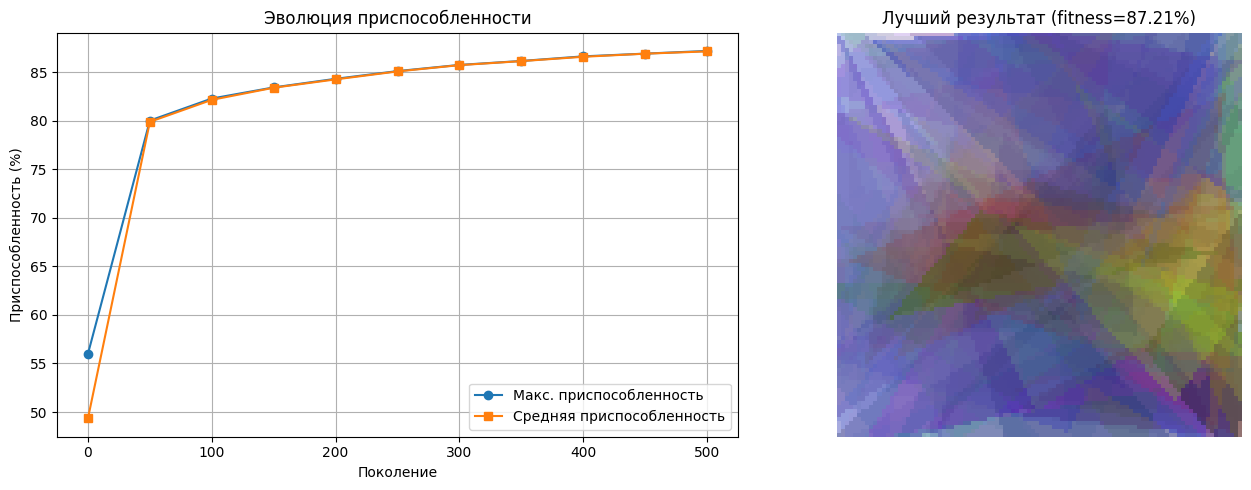

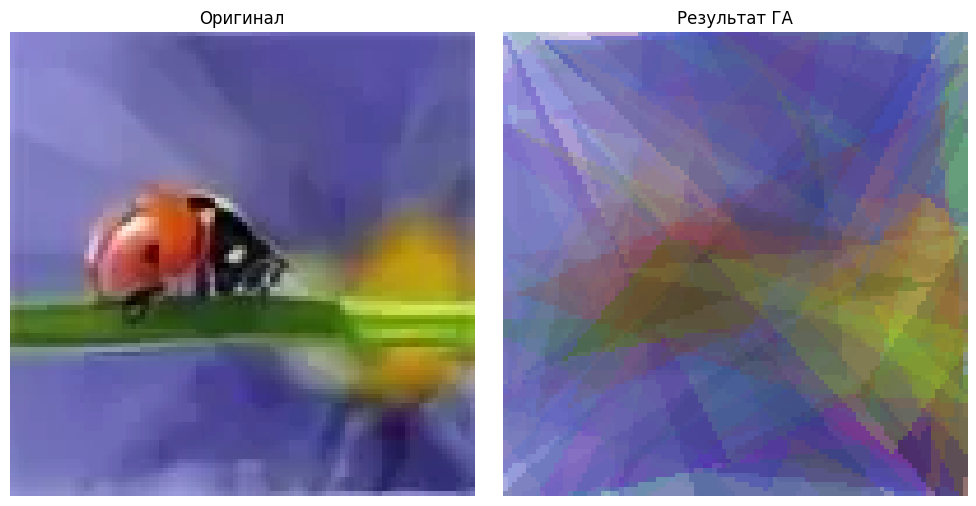

In [19]:
# Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График приспособленности
axes[0].plot(result["generation"], result["max_fitness"], label="Макс. приспособленность", marker='o')
axes[0].plot(result["generation"], result["avg_fitness"], label="Средняя приспособленность", marker='s')
axes[0].set_xlabel("Поколение")
axes[0].set_ylabel("Приспособленность (%)")
axes[0].set_title("Эволюция приспособленности")
axes[0].legend()
axes[0].grid(True)

# Лучший результат vs оригинал
best_path = result.iloc[-1]["outpath"]
best_img = Image.open(best_path)
axes[1].imshow(np.array(best_img))
axes[1].set_title(f"Лучший результат (fitness={result.iloc[-1]['max_fitness']:.2f}%)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Сравнение с оригиналом
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(np.array(target))
axes2[0].set_title("Оригинал")
axes2[0].axis('off')
axes2[1].imshow(np.array(best_img))
axes2[1].set_title("Результат ГА")
axes2[1].axis('off')
plt.tight_layout()
plt.show()